# Donation Value Post Regressor

## Problem Framing

**Business question:** Before publishing a social media post, how much donation value should the organization expect that post to generate?

**Why this matters:** This is a different business problem from the referral classifier. Instead of asking whether a post will generate at least one referral, this pipeline estimates the expected donation value attached to the post so staff can compare draft content, prioritize campaigns, and make better budget decisions.

**Primary user:** fundraising and marketing staff deciding which planned posts deserve priority placement, boost budget, or executive review.

**Modeling goal:**
- **Predictive model:** estimate the expected `estimated_donation_value_php` for future posts.
- **Explanatory companion model:** estimate directional relationships between pre-publish features and donation value while staying careful about causal language.

**Success metrics:**
- RMSE and MAE in PHP for practical forecast error.
- R-squared for variance explained.
- Ranking usefulness for comparing candidate posts.

**Target:** `estimated_donation_value_php`

**Important caution:** This target is highly skewed and contains many zeros, so it is harder to model cleanly than the referral classifier. This notebook handles that with log-transformed regression and communicates the limitations directly.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "ml-pipelines" else cwd
data_dir = repo_root / "lighthouse_csv_v7"
artifact_dir = repo_root / "ml-pipelines" / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

posts = pd.read_csv(data_dir / "social_media_posts.csv", parse_dates=["created_at"]).sort_values("created_at").reset_index(drop=True)
print("Posts shape:", posts.shape)

Posts shape: (812, 39)


## Data Acquisition, Preparation, and Exploration

This notebook uses the same post-level grain as the classifier: one row per social media post. That makes the model operational before publishing.

### Leakage rule
Only pre-publish features are used. All post-publication engagement metrics remain excluded.

### Selected features
To keep the pipeline clean and consistent with the earlier classifier, I use the same narrower pre-publish feature set:
- platform
- day of week
- post hour
- post type
- media type
- hashtag count
- CTA presence and CTA type
- content topic
- sentiment tone
- caption length
- resident story flag
- campaign name
- boosted flag and boost budget

In [2]:
selected_features = [
    "platform",
    "day_of_week",
    "post_hour",
    "post_type",
    "media_type",
    "num_hashtags",
    "has_call_to_action",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "caption_length",
    "features_resident_story",
    "campaign_name",
    "is_boosted",
    "boost_budget_php",
]
numeric_features = ["post_hour", "num_hashtags", "caption_length", "boost_budget_php"]
categorical_features = [col for col in selected_features if col not in numeric_features]

audit = pd.Series(
    {
        "rows": len(posts),
        "date_min": posts["created_at"].min(),
        "date_max": posts["created_at"].max(),
        "duplicate_post_id": int(posts["post_id"].duplicated().sum()),
        "invalid_post_hour": int(((posts["post_hour"] < 0) | (posts["post_hour"] > 23)).sum()),
        "negative_estimated_value": int((posts["estimated_donation_value_php"] < 0).sum()),
        "zero_value_rate": round((posts["estimated_donation_value_php"] == 0).mean(), 4),
        "positive_value_rate": round((posts["estimated_donation_value_php"] > 0).mean(), 4),
    }
).to_frame("value")

display(audit)
display(posts[selected_features].isna().mean().sort_values(ascending=False).rename("missing_rate").to_frame())

,value
rows,812
date_min,2023-01-05 18:52:00
date_max,2026-02-26 21:56:00
duplicate_post_id,0
invalid_post_hour,0
negative_estimated_value,0
zero_value_rate,0.3571
positive_value_rate,0.6429


,missing_rate
boost_budget_php,0.843596
campaign_name,0.714286
call_to_action_type,0.392857
platform,0.000000
day_of_week,0.000000
post_hour,0.000000
post_type,0.000000
media_type,0.000000
num_hashtags,0.000000
has_call_to_action,0.000000


,value
count,812.00
mean,39772.09
std,124081.12
min,0.00
50%,4556.96
75%,30072.07
90%,108224.70
95%,203109.22
99%,383166.07
max,2402435.96


,index,platform,count,mean,median
5,5,WhatsApp,93,78438.10,8737.10
6,6,YouTube,71,59060.76,9181.27
3,3,TikTok,89,57424.57,12476.39
2,2,LinkedIn,79,34921.29,0.00
0,0,Facebook,199,31086.19,3200.54
1,1,Instagram,164,30989.33,4322.74
4,4,Twitter,117,14264.21,3274.29


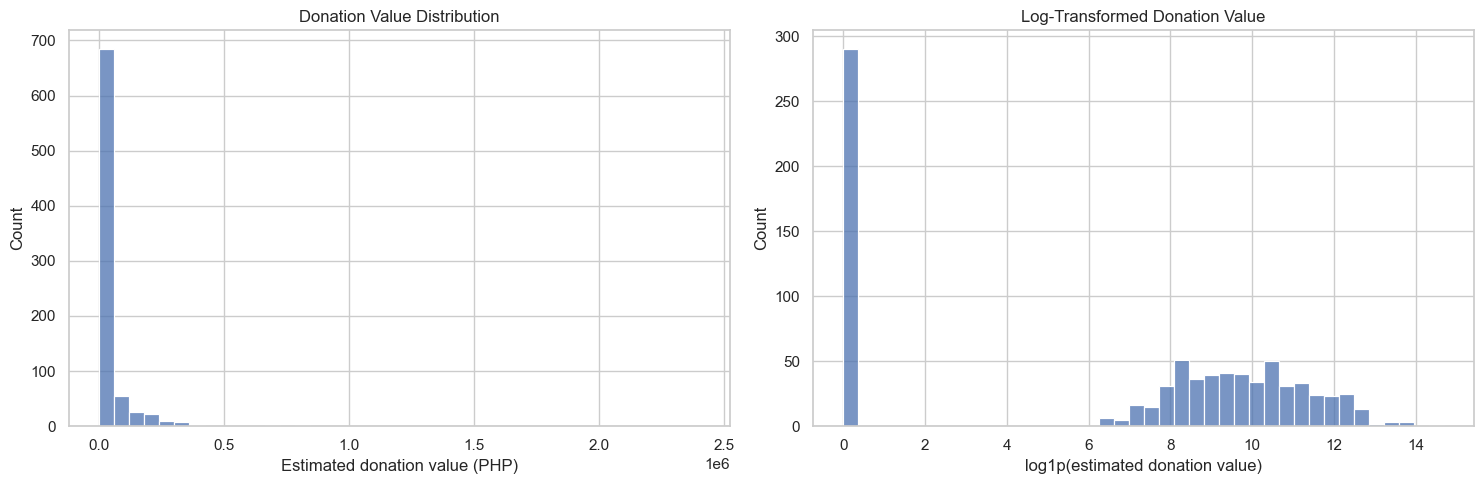

In [3]:
target_summary = posts["estimated_donation_value_php"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("value")
platform_value = posts.groupby("platform", as_index=False)["estimated_donation_value_php"].agg(["count", "mean", "median"]).reset_index().sort_values("mean", ascending=False)

display(target_summary.round(2))
display(platform_value.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(posts["estimated_donation_value_php"], bins=40, ax=axes[0])
axes[0].set_title("Donation Value Distribution")
axes[0].set_xlabel("Estimated donation value (PHP)")

sns.histplot(np.log1p(posts["estimated_donation_value_php"]), bins=40, ax=axes[1])
axes[1].set_title("Log-Transformed Donation Value")
axes[1].set_xlabel("log1p(estimated donation value)")

plt.tight_layout()
plt.show()

### Exploration takeaways
- The target is heavily right-skewed with a large mass at zero, so modeling raw PHP directly is unstable.
- A log-transformed target is more appropriate for both prediction and explanation.
- This pipeline should be interpreted as an estimate of expected value, not a precise accounting forecast for every individual post.

## Modeling and Feature Selection

As with the classifier, this notebook uses a time-aware split so later posts remain truly unseen at evaluation time.

I compare:
- **Ridge regression on log value** as the interpretable baseline.
- **Gradient boosting on log value** as a nonlinear benchmark.
- **Random forest on log value** as the main predictive model, with hyperparameter tuning.

This follows the PDF requirement to compare approaches and justify feature selection.

In [4]:
X = posts[selected_features].copy()
y = posts["estimated_donation_value_php"].copy()

split_index = int(len(posts) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = posts.iloc[split_index:]["created_at"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

time_cv = TimeSeriesSplit(n_splits=5)

ridge_model = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[("preprocessor", preprocessor), ("model", Ridge(alpha=1.0))]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

gbr_model = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[("preprocessor", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

rf_base = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42))]
    ),
    func=np.log1p,
    inverse_func=np.expm1,
)

rf_grid = {
    "regressor__model__n_estimators": [200, 400],
    "regressor__model__min_samples_leaf": [1, 3, 5],
    "regressor__model__max_depth": [None, 8, 12],
}

rf_search = GridSearchCV(
    rf_base,
    param_grid=rf_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

candidate_models = {
    "ridge_log": ridge_model,
    "gradient_boosting_log": gbr_model,
    "random_forest_log_tuned": best_rf,
}

rows = []
for name, model in candidate_models.items():
    cv_mae = []
    cv_rmse = []
    cv_r2 = []
    for train_idx, val_idx in time_cv.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_pred = model.predict(X_train.iloc[val_idx])
        cv_mae.append(mean_absolute_error(y_train.iloc[val_idx], val_pred))
        cv_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], val_pred)))
        cv_r2.append(r2_score(y_train.iloc[val_idx], val_pred))

    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    rows.append(
        {
            "model": name,
            "cv_mae": np.mean(cv_mae),
            "cv_rmse": np.mean(cv_rmse),
            "cv_r2": np.mean(cv_r2),
            "test_mae": mean_absolute_error(y_test, test_pred),
            "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
            "test_r2": r2_score(y_test, test_pred),
        }
    )

model_comparison = pd.DataFrame(rows).sort_values("test_mae")
display(model_comparison.round(2))
print("Best random forest parameters:", rf_search.best_params_)

,model,cv_mae,cv_rmse,cv_r2,test_mae,test_rmse,test_r2
2,random_forest_log_tuned,31532.20,93866.21,0.19,31603.95,82622.61,0.17
1,gradient_boosting_log,35397.01,105916.84,-0.22,32628.87,87029.52,0.08
0,ridge_log,80888.09,322315.74,-35.50,46167.37,165975.37,-2.36


Best random forest parameters: {'regressor__model__max_depth': 8, 'regressor__model__min_samples_leaf': 1, 'regressor__model__n_estimators': 200}


Final predictive model: tuned random forest regressor on log-transformed target
Holdout period: 2025-07-18 to 2026-02-26
Test MAE (PHP): 31603.95
Test RMSE (PHP): 82622.61
Test R-squared: 0.1666


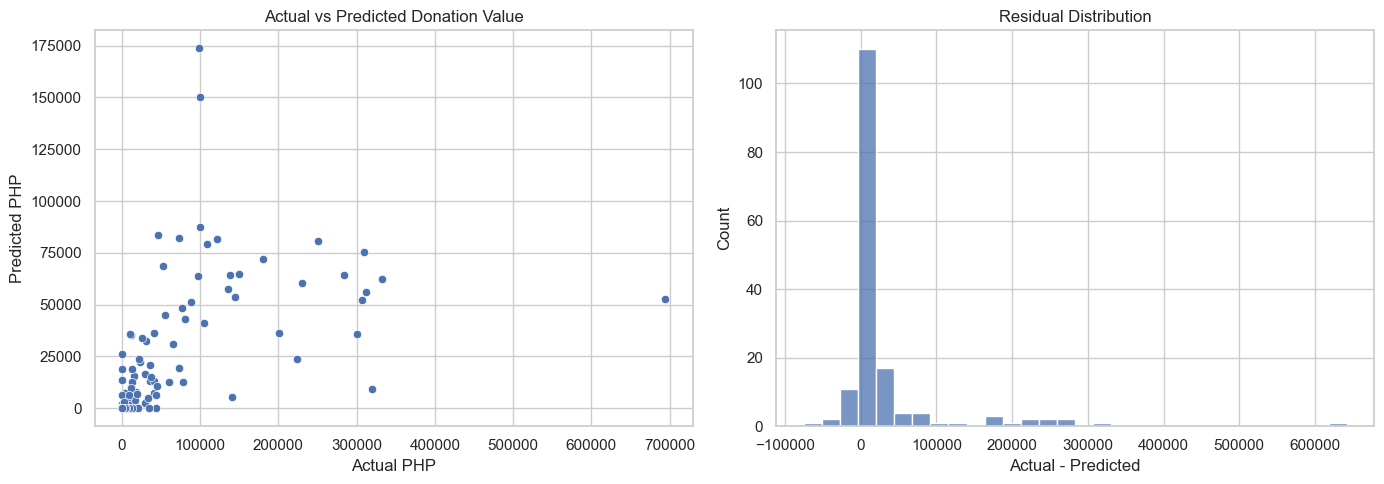

In [5]:
best_model = best_rf
test_pred = best_model.predict(X_test)
residuals = y_test - test_pred

print("Final predictive model: tuned random forest regressor on log-transformed target")
print("Holdout period:", test_dates.min().date(), "to", test_dates.max().date())
print("Test MAE (PHP):", round(mean_absolute_error(y_test, test_pred), 2))
print("Test RMSE (PHP):", round(np.sqrt(mean_squared_error(y_test, test_pred)), 2))
print("Test R-squared:", round(r2_score(y_test, test_pred), 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_test, y=test_pred, ax=axes[0])
axes[0].set_title("Actual vs Predicted Donation Value")
axes[0].set_xlabel("Actual PHP")
axes[0].set_ylabel("Predicted PHP")

sns.histplot(residuals, bins=30, ax=axes[1])
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
3,post_type,9667.3530,1245.6566
2,post_hour,4180.4917,684.8650
11,features_resident_story,3800.0380,668.6199
0,platform,1151.7669,342.7073
10,caption_length,763.4211,438.4875
6,has_call_to_action,577.0473,161.8130
7,call_to_action_type,446.8315,385.5913
5,num_hashtags,173.5212,147.0939
4,media_type,87.5103,223.1197
1,day_of_week,74.4699,196.8263


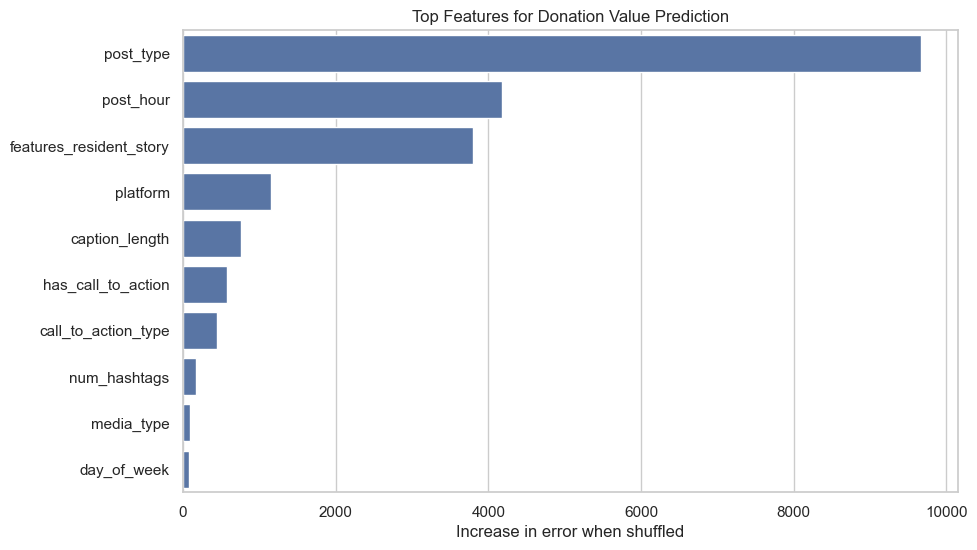

In [6]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(feature_importance.round(4))

sns.barplot(
    data=feature_importance.head(10),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title("Top Features for Donation Value Prediction")
plt.xlabel("Increase in error when shuffled")
plt.ylabel("")
plt.show()

### Which Predictors Matter Most According to the Model?

This code block tested which features the trained regression model relied on most when predicting donation value.

What it found:
- `post_type` mattered most
- `post_hour` was second
- `features_resident_story` was also very important
- `platform` mattered
- `has_call_to_action` and `call_to_action_type` mattered more here than they did in the referral notebook

So the main message is: the donation-value model cares most about **what kind of post it is**, **when it is posted**, and **whether it features a resident story**, with **CTA** playing a more important role here than in the referral notebook.

## Which Predictors of Donation Value Matter Most?

The donation-value model says the strongest pre-publish signals are **post type**, **post hour**, **resident story**, and then features like **CTA**, **platform**, and **caption setup**. This section tests the most important features directly in the historical data.

Because donation value is skewed, the code shows both **mean** and **median** value where helpful.

In [9]:
post_type_value_ranking = posts.groupby("post_type").agg(
    posts=("post_id", "size"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    median_estimated_value_php=("estimated_donation_value_php", "median"),
    positive_value_rate=("estimated_donation_value_php", lambda s: (s > 0).mean()),
).sort_values(["avg_estimated_value_php", "median_estimated_value_php"], ascending=False)

post_hour_value_ranking = posts.groupby("post_hour").agg(
    posts=("post_id", "size"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    median_estimated_value_php=("estimated_donation_value_php", "median"),
    positive_value_rate=("estimated_donation_value_php", lambda s: (s > 0).mean()),
).sort_values(["avg_estimated_value_php", "median_estimated_value_php"], ascending=False)

cta_value_ranking = posts.groupby("has_call_to_action").agg(
    posts=("post_id", "size"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    median_estimated_value_php=("estimated_donation_value_php", "median"),
    positive_value_rate=("estimated_donation_value_php", lambda s: (s > 0).mean()),
).sort_values(["avg_estimated_value_php", "median_estimated_value_php"], ascending=False)

resident_story_value_ranking = posts.groupby("features_resident_story").agg(
    posts=("post_id", "size"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    median_estimated_value_php=("estimated_donation_value_php", "median"),
    positive_value_rate=("estimated_donation_value_php", lambda s: (s > 0).mean()),
).sort_values(["avg_estimated_value_php", "median_estimated_value_php"], ascending=False)

sentiment_value_ranking = posts.groupby("sentiment_tone").agg(
    posts=("post_id", "size"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    median_estimated_value_php=("estimated_donation_value_php", "median"),
    positive_value_rate=("estimated_donation_value_php", lambda s: (s > 0).mean()),
).sort_values(["avg_estimated_value_php", "median_estimated_value_php"], ascending=False)

print("Post type test: which post types create the most donation value?")
display(post_type_value_ranking.round(3))
print("Posting hour test: which hours create the most donation value?")
display(post_hour_value_ranking.head(10).round(3))
print("Call-to-action test: does having a CTA change donation value?")
display(cta_value_ranking.round(3))
print("Resident story test: do posts featuring a resident story create more donation value?")
display(resident_story_value_ranking.round(3))
print("Sentiment tone test: which tone creates the strongest donation value?")
display(sentiment_value_ranking.round(3))

print("Best post type for average donation value in the dataset:", post_type_value_ranking.index[0])
print("Best posting hour for average donation value in the dataset:", int(post_hour_value_ranking.index[0]))
print("Best sentiment tone for average donation value in the dataset:", sentiment_value_ranking.index[0])

Post type test: which post types create the most donation value?


,posts,avg_estimated_value_php,median_estimated_value_php,positive_value_rate
post_type,,,,
ImpactStory,203,116160.672,45343.200,0.946
FundraisingAppeal,90,36155.811,12965.970,0.811
Campaign,156,28141.296,9799.005,0.821
EducationalContent,114,3183.232,0.000,0.351
ThankYou,118,2927.612,0.000,0.381
EventPromotion,131,2762.686,0.000,0.336


Posting hour test: which hours create the most donation value?


,posts,avg_estimated_value_php,median_estimated_value_php,positive_value_rate
post_hour,,,,
10,47,111170.070,19243.950,0.830
19,68,69080.626,14673.230,0.853
9,50,55678.024,15546.395,0.740
11,43,52243.899,4708.450,0.721
12,36,51561.481,10774.720,0.722
17,42,50261.060,8373.010,0.714
13,37,45996.025,15197.130,0.892
21,40,41700.802,5499.605,0.725
18,40,41581.650,11334.120,0.750


Call-to-action test: does having a CTA change donation value?


...

Resident story test: do posts featuring a resident story create more donation value?


,posts,avg_estimated_value_php,median_estimated_value_php,positive_value_rate
features_resident_story,,,,
True,165,132948.348,66592.79,0.97
False,647,16009.989,2046.00,0.56


Sentiment tone test: which tone creates the strongest donation value?


,posts,avg_estimated_value_php,median_estimated_value_php,positive_value_rate
sentiment_tone,,,,
Urgent,120,60336.685,5842.465,0.658
Emotional,138,56921.575,10820.420,0.725
Celebratory,113,56844.882,7389.560,0.743
Hopeful,149,30609.380,3617.660,0.644
Grateful,130,22917.672,4608.475,0.638
Informative,162,19974.037,0.000,0.494


Best post type for average donation value in the dataset: ImpactStory
Best posting hour for average donation value in the dataset: 10
Best sentiment tone for average donation value in the dataset: Urgent


### What These Feature Tests Found

This block tested the most important donation-value features directly in the observed data.

What it found:
- **Post type:** `ImpactStory` was strongest by a wide margin. `FundraisingAppeal` and `Campaign` were the next strongest post types. `EducationalContent`, `ThankYou`, and `EventPromotion` were weakest.
- **Post hour:** the best hour for average donation value in the observed data was `10` (10 AM). `19` (7 PM), `9` (9 AM), and `11` (11 AM) also looked strong.
- **Call to action:** this feature is mixed. Posts without a CTA had a higher mean value, but posts with a CTA had a higher median value and a higher positive-value rate. That suggests CTA may help consistency even if a few no-CTA outliers pulled the mean upward.
- **Resident story:** this was one of the clearest patterns in the notebook. Posts featuring a resident story had much higher average and median donation value.
- **Sentiment tone:** `Urgent`, `Emotional`, and `Celebratory` tones produced the strongest donation value in the observed data, while `Informative` was weakest.

These are descriptive patterns from the data. They help show why the model values some draft posts more highly than others.

## Evaluation and Interpretation

### Business interpretation
- This model is useful for **relative planning** even if post-level donation value remains noisy.
- MAE in PHP is the most practical metric here because it tells the team how far off the forecast is on average.
- The model is best used to compare candidate posts or forecast expected value bands, not to promise an exact donation total from one post.

### Error consequences
- **Overprediction:** staff may over-invest attention or boost budget in a post that underperforms.
- **Underprediction:** staff may overlook a post with unusually strong fundraising potential.

Because donation value is much noisier than referral occurrence, the safer production use is ranking and comparison rather than exact budgeting from a single prediction.

## Causal and Relationship Analysis

The PDF requires causal and relationship analysis for each pipeline. This section uses an explanatory linear model on `log1p(estimated_donation_value_php)`. It is interpretable, but it does **not** prove causal effects.

In [7]:
explain_df = posts.copy()
explain_df["campaign_name"] = explain_df["campaign_name"].fillna("NoCampaign")
explain_df["call_to_action_type"] = explain_df["call_to_action_type"].fillna("NoCTA")
explain_df["boost_budget_php"] = explain_df["boost_budget_php"].fillna(0)
explain_df["log_value"] = np.log1p(explain_df["estimated_donation_value_php"])

formula = (
    "log_value ~ C(platform) + C(day_of_week) + post_hour + C(post_type) + C(media_type) + "
    "num_hashtags + has_call_to_action + C(call_to_action_type) + C(content_topic) + "
    "C(sentiment_tone) + caption_length + features_resident_story + C(campaign_name) + "
    "is_boosted + boost_budget_php"
)

ols_model = smf.ols(formula=formula, data=explain_df).fit()
coef_table = pd.DataFrame(
    {
        "coefficient": ols_model.params,
        "p_value": ols_model.pvalues,
    }
).sort_values("p_value")
display(coef_table.head(20).round(4))

,coefficient,p_value
post_hour,0.2073,0.0000
C(post_type)[T.EventPromotion],-4.6092,0.0000
C(post_type)[T.EducationalContent],-4.3425,0.0000
C(post_type)[T.ThankYou],-4.5782,0.0000
C(sentiment_tone)[T.Informative],-2.2344,0.0000
has_call_to_action[T.True],1.8099,0.0000
Intercept,3.2845,0.0001
features_resident_story[T.True],2.1845,0.0002
C(call_to_action_type)[T.NoCTA],1.4746,0.0012
C(media_type)[T.Text],-1.3733,0.0024


### Relationship discussion
- If `post_type`, `post_hour`, `features_resident_story`, and `platform` appear near the top again, that suggests the same planning levers that influence referral likelihood also matter for donation value.
- A positive coefficient means the feature is associated with higher expected log donation value, holding other modeled features constant.
- These are associations, not proof of causality. The organization did not randomize platforms, content types, or budgets.

### Honest limitations
- Donation value is more volatile than referral occurrence.
- Extreme outliers can still dominate error metrics.
- This notebook is better for prioritization and comparison than for exact per-post accounting forecasts.

In [8]:
artifact_path = artifact_dir / "donation_value_random_forest_regressor.joblib"
joblib.dump(best_model, artifact_path)

sample_scoring = X_test.head(5).copy()
sample_scoring = sample_scoring.assign(predicted_donation_value_php=best_model.predict(sample_scoring))
print("Saved predictive pipeline to:", artifact_path)
display(sample_scoring.sort_values("predicted_donation_value_php", ascending=False))

Saved predictive pipeline to: /Users/jimmychurchill/Documents/Intex II/ml-pipelines/artifacts/donation_value_random_forest_regressor.joblib


,platform,day_of_week,post_hour,post_type,media_type,num_hashtags,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,predicted_donation_value_php
649,Instagram,Friday,17,ImpactStory,Photo,2,False,NaN,Gratitude,Celebratory,142,True,NaN,True,1265.17,79208.541975
652,Facebook,Sunday,20,Campaign,Text,2,True,SignUp,Gratitude,Hopeful,178,False,NaN,False,NaN,7549.185019
653,Twitter,Saturday,17,Campaign,Photo,1,True,SignUp,Health,Urgent,176,False,NaN,False,NaN,2516.822066
650,LinkedIn,Saturday,20,EventPromotion,Carousel,2,True,LearnMore,CampaignLaunch,Emotional,116,False,Back to School,False,NaN,227.251558
651,Instagram,Sunday,21,EducationalContent,Carousel,4,False,NaN,Education,Emotional,177,False,Back to School,False,NaN,103.446551


### Saved Model and Sample Predictions

This final code block is for deployment, not for feature testing.

It does two practical things:
- saves the trained regression model to a `.joblib` file
- shows sample predicted donation values for a few unseen posts

What the output means:
- each row is a post from the test set
- `predicted_donation_value_php` is the model's estimate of expected donation value for that post
- this is the type of number the app could use to compare draft posts before publishing

## Deployment Notes

The predictive artifact is saved to `ml-pipelines/artifacts/donation_value_random_forest_regressor.joblib`.

### Intended web-app integration
1. Add an endpoint such as `POST /api/ml/social-post-donation-value`.
2. Pass planned post metadata before publication.
3. Return the estimated donation value and optionally a value band such as low, medium, or high.
4. Use it inside a content planner or campaign ROI dashboard.

### Example scoring snippet
```python
import joblib
import pandas as pd

model = joblib.load("ml-pipelines/artifacts/donation_value_random_forest_regressor.joblib")

def score_planned_post_value(payload: dict) -> float:
    row = pd.DataFrame([payload])
    prediction = model.predict(row)[0]
    return float(prediction)
```

### Recommended use
- Compare candidate posts by expected value.
- Use the score alongside the referral classifier, not instead of it.
- Refit regularly as more campaign history accumulates.

This notebook is fully executable top to bottom with repo-relative paths.